In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score

In [91]:
N_users = 10000
N_times_train = 10
N_times_val = 5
N_times_prod = 5

# Put an average of 3 users in each category. Not perfect memorization.
N_categories = N_users // 3
# Bounds for the default probabilities
p_min = 0.01
p_max = 0.20

seed = 1235

In [92]:
# Transformations of parameters, do not change these

# Convert min and max probabilities into logits
z_max = np.log(p_max/(1-p_max))
z_min = np.log(p_min/(1-p_min))

In [93]:
# Generate the dataset
rng = np.random.default_rng(seed)

dataset = []  # (t, x0, x1, y)

for idx_user in range(N_users):
    z_user = rng.uniform(low=z_min, high=z_max)
    p_user = 1 / (1 + np.exp(-z_user))
    cat_user = rng.choice(N_categories)
    # Run a simulation forward in time to determine when the user defaults (if ever)
    for t in range(N_times_train + N_times_val + N_times_prod):
        does_user_default = rng.binomial(p=p_user, n=1)
        dataset.append((t, z_user, cat_user, does_user_default))
        if does_user_default:
            break

# Make it a pandas DataFrame for easier manipulation
dataset_pd = pd.DataFrame(
    dataset,
    columns=['t', 'x0', 'x1', 'y']
)

In [94]:
# Fit a simple model to the training data and show that the regression coefficient is 1.0
lr_simple_model = LogisticRegression()
lr_simple_model.fit(
    X = dataset_pd[dataset_pd['t'] < N_times_train][['x0']],
    y = dataset_pd[dataset_pd['t'] < N_times_train]['y'],
)

print(f'Regression coefficient of simple model: {lr_simple_model.coef_[0, 0]}')

Regression coefficient of simple model: 1.00544310944754


In [98]:
# This section gets affected by our choice of val scheme
df_train = dataset_pd[dataset_pd['t'] < N_times_train]
df_val = dataset_pd[(dataset_pd['t'] >= N_times_train) & (dataset_pd['t'] < N_times_train + N_times_val)]

# Everything below here does not
df_retrain = dataset_pd[dataset_pd['t'] < N_times_train + N_times_val]
df_prod = dataset_pd[dataset_pd['t'] > N_times_train + N_times_val]

X_train = df_train.drop(columns=['t', 'y'])
y_train = df_train['y']

X_val = df_val.drop(columns=['t', 'y'])
y_val = df_val['y']

preprocessor = ColumnTransformer(
    transformers=[
        ('none', 'passthrough', ['x0']),
        ('one-hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['x1'])
    ]
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression())
    ]
)

pipeline.fit(X_train, y_train)

roc_auc_train = roc_auc_score(y_true=y_train, y_score=pipeline.predict_proba(X_train)[:, 1])
roc_auc_val = roc_auc_score(y_true=y_val, y_score=pipeline.predict_proba(X_val)[:, 1])

# Retrain for prod
X_retrain = df_retrain.drop(columns=['t', 'y'])
y_retrain = df_retrain['y']

X_prod = df_prod.drop(columns=['t', 'y'])
y_prod = df_prod['y']

pipeline.fit(X_retrain, y_retrain)
roc_auc_retrain = roc_auc_score(y_true=y_retrain, y_score=pipeline.predict_proba(X_retrain)[:, 1])
roc_auc_prod = roc_auc_score(y_true=y_prod, y_score=pipeline.predict_proba(X_prod)[:, 1])

In [99]:
roc_auc_train, roc_auc_val, roc_auc_retrain, roc_auc_prod

(np.float64(0.7979024975981677),
 np.float64(0.7029342443749658),
 np.float64(0.7895665808047148),
 np.float64(0.6734495759898789))

In [96]:
roc_auc_score(y_true=y_train, y_score=pipeline.predict_proba(X_train)[:, 1])

np.float64(0.7979024975981677)

In [97]:
roc_auc_score(y_true=y_val, y_score=pipeline.predict_proba(X_val)[:, 1])

np.float64(0.7029342443749658)

In [83]:
pipeline.steps[1][1].coef_

array([[ 1.09118117,  0.54830075, -0.38030474, ...,  0.65321222,
        -0.02524466,  0.02041469]])

In [55]:
l_vals = np.linspace(-4.0, -1.5, 1000)
p_vals = 1 / (1 + np.exp(-l_vals))

In [56]:
p_vals[-1]

np.float64(0.18242552380635635)

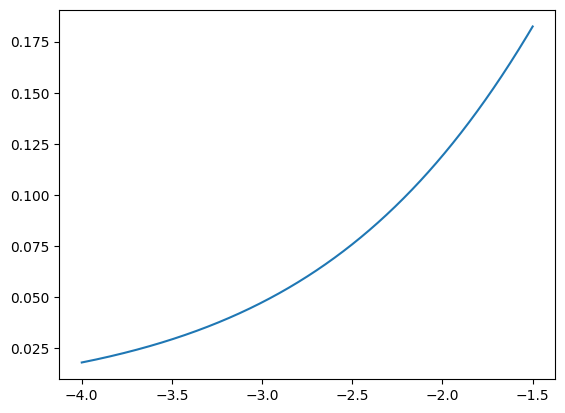

In [57]:
plt.plot(l_vals, p_vals)